# EDA

## Обзор данных

In [1]:
import pandas as pd
from sklearn.pipeline import make_pipeline

from notebooks.learning import xgboost_model

In [2]:
df = pd.read_csv('../data/train.csv')

In [3]:
df

,id,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,loan_status
0,0,37,35000,RENT,0.0,EDUCATION,B,6000,11.49,0.17,N,14,0
1,1,22,56000,OWN,6.0,MEDICAL,C,4000,13.35,0.07,N,2,0
2,2,29,28800,OWN,8.0,PERSONAL,A,6000,8.90,0.21,N,10,0
3,3,30,70000,RENT,14.0,VENTURE,B,12000,11.11,0.17,N,5,0
4,4,22,60000,RENT,2.0,MEDICAL,A,6000,6.92,0.10,N,3,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
58640,58640,34,120000,MORTGAGE,5.0,EDUCATION,D,25000,15.95,0.21,Y,10,0
58641,58641,28,28800,RENT,0.0,MEDICAL,C,10000,12.73,0.35,N,8,1
58642,58642,23,44000,RENT,7.0,EDUCATION,D,6800,16.00,0.15,N,2,1
58643,58643,22,30000,RENT,2.0,EDUCATION,A,5000,8.90,0.17,N,3,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 58645 entries, 0 to 58644
Data columns (total 13 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   id                          58645 non-null  int64  
 1   person_age                  58645 non-null  int64  
 2   person_income               58645 non-null  int64  
 3   person_home_ownership       58645 non-null  object 
 4   person_emp_length           58645 non-null  float64
 5   loan_intent                 58645 non-null  object 
 6   loan_grade                  58645 non-null  object 
 7   loan_amnt                   58645 non-null  int64  
 8   loan_int_rate               58645 non-null  float64
 9   loan_percent_income         58645 non-null  float64
 10  cb_person_default_on_file   58645 non-null  object 
 11  cb_person_cred_hist_length  58645 non-null  int64  
 12  loan_status                 58645 non-null  int64  
dtypes: float64(3), int64(6), object

In [5]:
df.describe()

,id,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,loan_status
count,58645.000000,58645.000000,5.864500e+04,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000,58645.000000
mean,29322.000000,27.550857,6.404617e+04,4.701015,9217.556518,10.677874,0.159238,5.813556,0.142382
std,16929.497605,6.033216,3.793111e+04,3.959784,5563.807384,3.034697,0.091692,4.029196,0.349445
min,0.000000,20.000000,4.200000e+03,0.000000,500.000000,5.420000,0.000000,2.000000,0.000000
25%,14661.000000,23.000000,4.200000e+04,2.000000,5000.000000,7.880000,0.090000,3.000000,0.000000
50%,29322.000000,26.000000,5.800000e+04,4.000000,8000.000000,10.750000,0.140000,4.000000,0.000000
75%,43983.000000,30.000000,7.560000e+04,7.000000,12000.000000,12.990000,0.210000,8.000000,0.000000
max,58644.000000,123.000000,1.900000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000,1.000000


## Анализ целевой переменной

<Axes: xlabel='loan_status', ylabel='count'>

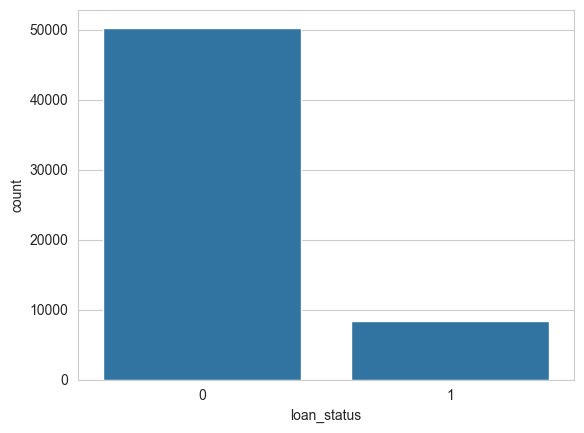

In [6]:
import seaborn as sns

sns.countplot(x=df['loan_status'])

In [7]:
df['loan_status'].value_counts(normalize=True) * 100

loan_status
0    85.761787
1    14.238213
Name: proportion, dtype: float64

Удалим столбец "id" из данных

In [ ]:
df.drop(columns=['id'], inplace=True, axis=1)

## Отчет по данным

In [8]:
from ydata_profiling import ProfileReport

profile = ProfileReport(df, title="Profiling report")
profile

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 13/13 [00:00<00:00, 401.72it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

## Матрица корреляций

interval columns not set, guessing: ['id', 'person_age', 'person_income', 'person_emp_length', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_cred_hist_length', 'loan_status']


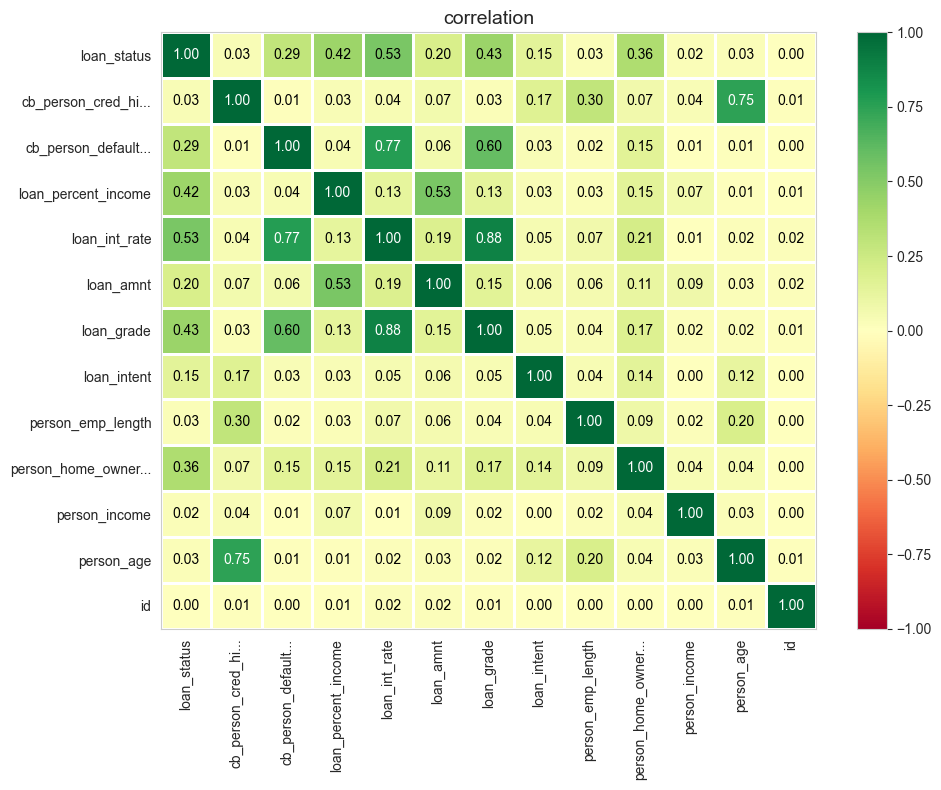

In [9]:
from phik.report import plot_correlation_matrix

corr_matrix = df.phik_matrix()
plot_correlation_matrix(corr_matrix.values, x_labels=corr_matrix.columns, y_labels=corr_matrix.index, figsize=(10, 8))

In [11]:
from sklearn.preprocessing import LabelEncoder

df['loan_grade'] = df['loan_grade'].map({'A':0, 'B':1, 'C':2, 'D':3, 'E':4, 'F':5, 'G':6})
df['cb_person_default_on_file'] = df['cb_person_default_on_file'].map({'N': 0, 'Y': 1})

categorical_cols = df.select_dtypes(include=['object']).columns

le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le
    print(f"   • {col}: {len(le.classes_)} категорий")

   • person_home_ownership: 4 категорий
   • loan_intent: 6 категорий


Корреляционная матрица числовых признаков от цели:

person_income                -0.169956
person_emp_length            -0.100428
loan_intent                  -0.048751
id                           -0.008138
cb_person_cred_hist_length   -0.003030
person_age                   -0.001130
loan_amnt                     0.144982
cb_person_default_on_file     0.186962
person_home_ownership         0.220167
loan_int_rate                 0.338948
loan_percent_income           0.378280
loan_grade                    0.385908
dtype: float64


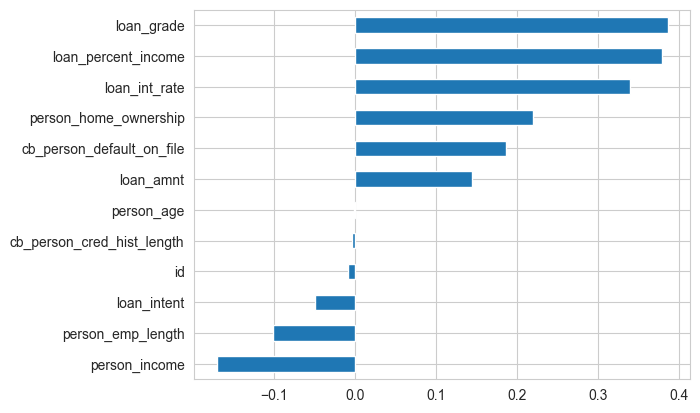

In [12]:
target_corrm = df.corrwith(df['loan_status']).drop(['loan_status']).sort_values()
target_corrm.plot(kind='barh')
print('Корреляционная матрица числовых признаков от цели:\n')
print(target_corrm)

# Построение классов для дальнейшей работы

## Класс для быстрого формирования предобработанного датасета

In [14]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from typing import Dict, List, Optional, Union, Tuple
import warnings
from sklearn.model_selection import train_test_split

class LoanDataPreprocessor:
    def __init__(
            self,
            df_path: Optional[str] = None,
            df: Optional[pd.DataFrame] = None,
            age_threshold: int = 122,
            emp_length_threshold: int = 104,
            drop_columns: Optional[List[str]] = None,
            manual_mappings: Optional[Dict] = None,
            target_column: str = 'loan_status',
            exclude_from_features: Optional[List[str]] = None,
            test_size: float = 0.2,
            random_state: int = 42
    ):
        if df_path and df is not None:
            warnings.warn("Указаны и df_path и df, будет использован df_path")

        self.df_path = df_path
        self.raw_df = df.copy() if df is not None else None
        self.age_threshold = age_threshold
        self.emp_length_threshold = emp_length_threshold
        self.drop_columns = drop_columns or ['loan_int_rate', 'person_age', 'id']
        self.manual_mappings = manual_mappings or {
            'loan_grade': {'A': 0, 'B': 1, 'C': 2, 'D': 3, 'E': 4, 'F': 5, 'G': 6},
            'cb_person_default_on_file': {'N': 0, 'Y': 1}
        }
        self.label_encoders: Dict[str, LabelEncoder] = {}
        self.preprocessing_info: Dict = {}
        self.exclude_from_features = exclude_from_features or []
        self.target_column = target_column
        self.feature_columns: Optional[List[str]] = None
        self.test_size = test_size
        self.random_state = random_state
        self.is_fitted = False

    def load_data(self) -> pd.DataFrame:
        if self.df_path is None:
            raise ValueError("Не указан путь к файлу (df_path)")

        self.raw_df = pd.read_csv(self.df_path)
        return self.raw_df

    def fit_encode_categorical(self, df: pd.DataFrame, verbose: bool = False) -> pd.DataFrame:
        df_encoded = df.copy()

        for col, mapping in self.manual_mappings.items():
            if col in df_encoded.columns:
                df_encoded[col] = df_encoded[col].map(mapping)
                if verbose:
                    print(f"   • {col}: применен ручной маппинг ({len(mapping)} категорий)")

        categorical_cols = df_encoded.select_dtypes(include=['object']).columns

        self.label_encoders = {}
        for col in categorical_cols:
            le = LabelEncoder()
            df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))
            self.label_encoders[col] = le

            if verbose:
                print(f"   • {col}: обучен на {len(le.classes_)} категориях")

        self.is_fitted = True
        self.preprocessing_info['encoding'] = {
            'manual_features': list(self.manual_mappings.keys()),
            'auto_features': list(categorical_cols),
            'label_encoders_count': len(self.label_encoders),
            'encoder_classes': {col: list(le.classes_) for col, le in self.label_encoders.items()}
        }

        return df_encoded

    def transform_encode_categorical(self, df: pd.DataFrame, verbose: bool = False) -> pd.DataFrame:
        if not self.is_fitted:
            raise ValueError("Энкодеры не обучены. Сначала вызовите fit_encode_categorical на тренировочных данных")

        df_encoded = df.copy()

        for col, mapping in self.manual_mappings.items():
            if col in df_encoded.columns:
                df_encoded[col] = df_encoded[col].map(mapping)
                df_encoded[col] = df_encoded[col].apply(lambda x: x if pd.notnull(x) else -1)

        for col, le in self.label_encoders.items():
            if col in df_encoded.columns:
                df_encoded[col] = df_encoded[col].apply(
                    lambda x: le.transform([x])[0] if str(x) in le.classes_ else -1
                )

        return df_encoded

    def filter_outliers(self, df: pd.DataFrame) -> pd.DataFrame:
        initial_size = len(df)

        mask_age = df['person_age'] <= self.age_threshold
        df_filtered = df[mask_age]
        removed_age = initial_size - len(df_filtered)

        mask_emp = df_filtered['person_emp_length'] <= self.emp_length_threshold
        df_filtered = df_filtered[mask_emp]
        removed_emp = initial_size - removed_age - len(df_filtered)

        self.preprocessing_info['filtering'] = {
            'initial_size': initial_size,
            'final_size': len(df_filtered),
            'removed_age': removed_age,
            'removed_emp': removed_emp,
            'age_threshold': self.age_threshold,
            'emp_threshold': self.emp_length_threshold
        }

        return df_filtered

    def split_features_target(self, df: pd.DataFrame) -> Tuple[pd.DataFrame, pd.Series]:
        if self.target_column not in df.columns:
            raise ValueError(f"Целевая колонка '{self.target_column}' не найдена в данных")

        all_columns = list(df.columns)
        columns_to_exclude = [self.target_column] + self.exclude_from_features

        feature_columns = [col for col in all_columns if col not in columns_to_exclude]
        self.feature_columns = feature_columns

        X = df[feature_columns]
        y = df[self.target_column]

        self.preprocessing_info['split'] = {
            'feature_columns': feature_columns,
            'target_column': self.target_column,
            'X_shape': X.shape,
            'y_shape': y.shape
        }

        return X, y

    def prepare_train_test_split(self, verbose: bool = False) -> Tuple:

        if self.raw_df is None and self.df_path:
            self.load_data()
        elif self.raw_df is None:
            raise ValueError("Нет данных для обработки")

        df = self.raw_df.copy()

        if verbose:
            print(f"Исходный размер датасета: {len(df)}")

        df = self.filter_outliers(df)

        if verbose:
            print(f"Размер после фильтрации выбросов: {len(df)}")

        train_df, test_df = train_test_split(
            df,
            test_size=self.test_size,
            random_state=self.random_state,
            stratify=df[self.target_column] if self.target_column in df.columns else None
        )

        if verbose:
            print(f"Train size: {len(train_df)}, Test size: {len(test_df)}")

        cols_to_drop = [col for col in self.drop_columns if col in train_df.columns]
        train_df = train_df.drop(columns=cols_to_drop)
        test_df = test_df.drop(columns=cols_to_drop)

        if verbose:
            print("\nКодирование категориальных признаков...")
            print("Обучение энкодеров на тренировочных данных:")

        train_df_encoded = self.fit_encode_categorical(train_df, verbose=verbose)

        if verbose:
            print("\nПрименение энкодеров к тестовым данным:")

        test_df_encoded = self.transform_encode_categorical(test_df, verbose=verbose)

        X_train, y_train = self.split_features_target(train_df_encoded)
        X_test, y_test = self.split_features_target(test_df_encoded)

        if verbose:
            print(f"\nИтоговые размеры:")
            print(f"X_train: {X_train.shape}, y_train: {y_train.shape}")
            print(f"X_test: {X_test.shape}, y_test: {y_test.shape}")

        return X_train, X_test, y_train, y_test

    def preprocess_train(self, df: pd.DataFrame, verbose: bool = False) -> pd.DataFrame:
        df_processed = df.copy()

        cols_to_drop = [col for col in self.drop_columns if col in df_processed.columns]
        if cols_to_drop:
            df_processed = df_processed.drop(columns=cols_to_drop)

        df_processed = self.fit_encode_categorical(df_processed, verbose=verbose)
        return df_processed

    def preprocess_test(self, df: pd.DataFrame, verbose: bool = False) -> pd.DataFrame:
        if not self.is_fitted:
            raise ValueError("Сначала обучите препроцессор на тренировочных данных (preprocess_train)")

        df_processed = df.copy()

        cols_to_drop = [col for col in self.drop_columns if col in df_processed.columns]
        if cols_to_drop:
            df_processed = df_processed.drop(columns=cols_to_drop)

        df_processed = self.transform_encode_categorical(df_processed, verbose=verbose)
        return df_processed

    def get_info(self) -> Dict:
        return self.preprocessing_info.copy()

    def get_label_encoders(self) -> Dict[str, LabelEncoder]:
        return self.label_encoders.copy()

    def save_encoders(self, path: str):
        import joblib
        joblib.dump({
            'label_encoders': self.label_encoders,
            'manual_mappings': self.manual_mappings,
            'feature_columns': self.feature_columns,
            'is_fitted': self.is_fitted
        }, path)

    def load_encoders(self, path: str):
        import joblib
        data = joblib.load(path)
        self.label_encoders = data['label_encoders']
        self.manual_mappings = data['manual_mappings']
        self.feature_columns = data['feature_columns']
        self.is_fitted = data['is_fitted']

In [15]:
preprocessor = LoanDataPreprocessor(
    df_path='../data/train.csv',
    age_threshold=122,
    emp_length_threshold=104,
    drop_columns=['loan_int_rate', 'person_age', 'id'],
    target_column='loan_status',
)

In [16]:
X_train, X_test, y_train, y_test = preprocessor.prepare_train_test_split(verbose=True)

Исходный размер датасета: 58645
Размер после фильтрации выбросов: 58642
Train size: 46913, Test size: 11729

Кодирование категориальных признаков...
Обучение энкодеров на тренировочных данных:
   • loan_grade: применен ручной маппинг (7 категорий)
   • cb_person_default_on_file: применен ручной маппинг (2 категорий)
   • person_home_ownership: обучен на 4 категориях
   • loan_intent: обучен на 6 категориях

Применение энкодеров к тестовым данным:

Итоговые размеры:
X_train: (46913, 9), y_train: (46913,)
X_test: (11729, 9), y_test: (11729,)


## Класс для визуализации

In [80]:
import plotly.graph_objects as go
import plotly.express as px
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score, average_precision_score
from sklearn.metrics import confusion_matrix
import numpy as np
from sklearn.metrics import roc_curve, auc, precision_recall_curve
# from sklearn.model_selection import cross_val_predict, StratifiedKFold
import os

class ModelVisualizer:
    def __init__(self, model, X: np.ndarray, y: np.ndarray):
        self.model = model
        self.X = X
        self.y = y

    def _get_predictions(self):
        return self.model.predict_proba(self.X)[:, 1]

    def save_figure(self, fig: go.Figure, filename: str, file_format: str = 'png') -> None:
        if not os.path.exists('visualizations'):
            os.makedirs('visualizations')  # Создаем папку для сохранения, если ее нет

        file_path = os.path.join('visualizations', f"{filename}.{file_format}")
        fig.write_image(file_path)  # Сохраняем изображение
        print(f"График сохранен в {file_path}")

    def plot_roc_curve(self) -> None:
        y_pred_proba = self._get_predictions()
        fpr, tpr, thresholds = roc_curve(self.y, y_pred_proba)
        roc_auc = auc(fpr, tpr)

        fig = go.Figure()

        fig.add_trace(go.Scatter(x=fpr, y=tpr, mode='lines', name=f'ROC curve (AUC = {roc_auc:.2f})'))
        fig.add_trace(go.Scatter(x=[0, 1], y=[0, 1], mode='lines', name='Random', line={'dash': 'dash'}))

        fig.update_layout(
            title="ROC Curve",
            xaxis_title="False Positive Rate",
            yaxis_title="True Positive Rate",
            showlegend=True
        )

        fig.show()

    def plot_precision_recall_curve(self) -> go.Figure:
        y_pred_proba = self._get_predictions()
        precision, recall, _ = precision_recall_curve(self.y, y_pred_proba)

        fig = go.Figure()

        fig.add_trace(go.Scatter(x=recall, y=precision, mode='lines', name="Precision-Recall curve"))

        fig.update_layout(
            title="Precision-Recall Curve",
            xaxis_title="Recall",
            yaxis_title="Precision",
            showlegend=True
        )

        return fig

    def plot_confusion_matrix(self) -> go.Figure:
        y_pred = self.model.predict(self.X)
        cm = confusion_matrix(self.y, y_pred)

        cm_df = pd.DataFrame(cm, index=['True Class 0', 'True Class 1'], columns=['Predicted 0', 'Predicted 1'])

        fig = px.imshow(cm_df, text_auto=True, color_continuous_scale='Blues', title='Confusion Matrix')

        fig.update_layout(
            xaxis_title="Predicted Labels",
            yaxis_title="True Labels",
            showlegend=False
        )

        return fig

    def plot_metrics_comparison(self) -> go.Figure:
        y_pred_proba = self._get_predictions()

        roc_auc = roc_auc_score(self.y, y_pred_proba)
        pr_auc = average_precision_score(self.y, y_pred_proba)
        precision = precision_score(self.y, (y_pred_proba > 0.5))
        recall = recall_score(self.y, (y_pred_proba > 0.5))
        f1 = f1_score(self.y, (y_pred_proba > 0.5))

        metrics = ['ROC AUC', 'PR AUC', 'Precision', 'Recall', 'F1']
        values = [roc_auc, pr_auc, precision, recall, f1]

        fig = go.Figure([go.Bar(x=metrics, y=values, marker=dict(color='royalblue'))])

        fig.update_layout(
            title="Model Performance Metrics",
            xaxis_title="Metrics",
            yaxis_title="Value",
            showlegend=False
        )

        print(f"ROC AUC: {roc_auc:.4f}")
        print(f"PR AUC: {pr_auc:.4f}")
        print(f"Precision: {precision:.4f}")
        print(f"Recall: {recall:.4f}")
        print(f"F1 Score: {f1:.4f}")

        return fig

    def plot_feature_importance(self) -> None:
        if hasattr(self.model.named_steps['classifier'], 'feature_importances_'):
            feature_importance = self.model.feature_importances_
            feature_names = self.X.columns if hasattr(self.X, 'columns') else [f'Feature {i}' for i in range(len(feature_importance))]

            fig = go.Figure()

            fig.add_trace(go.Barh(y=feature_names, x=feature_importance, orientation='h'))

            fig.update_layout(
                title='Feature Importance',
                xaxis_title='Feature Importance',
                yaxis_title='Feature Names',
                showlegend=False
            )

            fig.show()

        elif hasattr(self.model, 'coef_'):
            coef = self.model.coef_.flatten()
            feature_importance = abs(coef)
            feature_names = self.X.columns if hasattr(self.X, 'columns') else [f'Feature {i}' for i in range(len(feature_importance))]

            fig = go.Figure()

            fig.add_trace(go.Barh(y=feature_names, x=feature_importance, orientation='h'))

            fig.update_layout(
                title='Feature Importance (absolute coefficients)',
                xaxis_title='Feature Importance (absolute coefficients)',
                yaxis_title='Feature Names',
                showlegend=False
            )

            fig.show()
        else:
            print("Модель не поддерживает отображение важности признаков.")


## Базовый класс модели

In [18]:
from abc import ABC, abstractmethod
from typing import Dict, List, Optional, Union, Any
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, precision_score, recall_score, f1_score, \
    roc_auc_score, average_precision_score, accuracy_score
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt
import seaborn as sns


class BaseModel(ABC):
    def __init__(self, random_state: int = 42):
        self.random_state = random_state
        self.model = None
        self.best_params_ = None
        self.best_score_ = None

    @abstractmethod
    def create_pipeline(self) -> Pipeline:
        pass

    @abstractmethod
    def get_param_grid(self) -> List[Dict]:
        pass

    def train(self, X_train: np.ndarray, y_train: np.ndarray, cv: int = 3,
              scoring: str = 'roc_auc', n_jobs: int = -1) -> None:

        pipeline = self.create_pipeline()
        param_grid = self.get_param_grid()

        skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=self.random_state)

        gs = GridSearchCV(
            pipeline,
            param_grid=param_grid,
            cv=skf,
            scoring=scoring,
            n_jobs=n_jobs
        )

        gs.fit(X_train, y_train)

        self.model = gs.best_estimator_
        self.best_params_ = gs.best_params_
        self.best_score_ = gs.best_score_

        print(f'Лучшие параметры: {self.best_params_}')
        print(f'Лучшее качество на кросс-валидации: {self.best_score_:.4f}')

    def evaluate(self, X_test: np.ndarray, y_test: np.ndarray,
                 cv: int = 3, n_jobs: int = -1,
                 plot_confusion_matrix: bool = True) -> Dict[str, Any]:
        if self.model is None:
            raise ValueError("Модель не обучена. Сначала вызовите метод train()")
        y_pred = self.model.predict(X_test)

        y_proba = self.model.predict_proba(X_test)[:, 1] if hasattr(self.model, "predict_proba") else None

        report = classification_report(y_test, y_pred)

        cm = confusion_matrix(y_test, y_pred)

        if plot_confusion_matrix:
            plt.figure(figsize=(8, 6))
            sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
            plt.title('Confusion Matrix на тестовых данных')
            plt.ylabel('True Label')
            plt.xlabel('Predicted Label')
            plt.show()

        metrics = {
            'accuracy': accuracy_score(y_test, y_pred),
            'precision': precision_score(y_test, y_pred, zero_division=0),
            'recall': recall_score(y_test, y_pred, zero_division=0),
            'f1': f1_score(y_test, y_pred, zero_division=0),
        }

        if y_proba is not None and len(np.unique(y_test)) == 2:
            metrics['roc_auc'] = roc_auc_score(y_test, y_proba)
            metrics['average_precision'] = average_precision_score(y_test, y_proba)

        return {
            'classification_report': report,
            'confusion_matrix': cm,
            'metrics': metrics,
            'y_pred': y_pred,
            'y_proba': y_proba
        }

    def predict(self, X: np.ndarray) -> np.ndarray:
        if self.model is None:
            raise ValueError("Модель не обучена. Сначала вызовите метод train()")
        return self.model.predict(X)

    def predict_proba(self, X: np.ndarray) -> np.ndarray:
        if self.model is None:
            raise ValueError("Модель не обучена. Сначала вызовите метод train()")
        return self.model.predict_proba(X)

## Логистическая регрессия

In [26]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

class LogisticRegressionModel(BaseModel):

    def __init__(self, random_state: int = 42,
                 class_weight_options: List = None):
        super().__init__(random_state)
        self.class_weight_options = class_weight_options or ['balanced', None]

    def create_pipeline(self) -> Pipeline:
        return make_pipeline(
            StandardScaler(),
            LogisticRegression(
                random_state=self.random_state,
                n_jobs=-1,
                max_iter=1000
            )
        )

    def get_param_grid(self) -> List[Dict]:
        return [
            {
                'logisticregression__penalty': ['l1'],
                'logisticregression__C': np.linspace(0.1, 100, 10),
                'logisticregression__solver': ['saga'],
                'logisticregression__class_weight': self.class_weight_options
            },
            {
                'logisticregression__penalty': ['l2'],
                'logisticregression__C': np.linspace(0.1, 100, 10),
                'logisticregression__solver': ['lbfgs', 'saga'],
                'logisticregression__class_weight': self.class_weight_options
            },
            {
                'logisticregression__penalty': ['elasticnet'],
                'logisticregression__C': np.linspace(0.1, 100, 10),
                'logisticregression__l1_ratio': np.linspace(0, 1, 10),
                'logisticregression__solver': ['saga'],
                'logisticregression__class_weight': self.class_weight_options
            },
            {
                'logisticregression__penalty': [None],
                'logisticregression__solver': ['lbfgs', 'newton-cg', 'saga'],
                'logisticregression__class_weight': self.class_weight_options
            }
        ]

    def plot_threshold_analysis(self, X_test: np.ndarray, y_test: np.ndarray):
        if self.model is None:
            raise ValueError("Модель не обучена. Сначала вызовите метод train()")

        y_proba_pred = self.model.predict_proba(X_test)[:, 1]

        thresholds = np.arange(0.1, 1, 0.05)
        recall_scores = []
        precision_scores = []
        f1_scores = []

        for threshold in thresholds:
            y_pred = (y_proba_pred > threshold).astype(int)
            recall_scores.append(recall_score(y_test, y_pred, zero_division=0))
            precision_scores.append(precision_score(y_test, y_pred, zero_division=0))
            f1_scores.append(f1_score(y_test, y_pred, zero_division=0))

        plt.figure(figsize=(12, 6))
        plt.plot(thresholds, recall_scores, label='Recall', marker='o')
        plt.plot(thresholds, precision_scores, label='Precision', marker='s')
        plt.plot(thresholds, f1_scores, label='F1-score', marker='^')

        plt.title('Зависимость метрик от порога вероятности')
        plt.xlabel('Порог вероятности')
        plt.ylabel('Метрика')
        plt.xticks(thresholds, rotation=45)
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()
        plt.show()

In [27]:
lr_model = LogisticRegressionModel(random_state=42)

In [28]:
lr_model.train(X_train, y_train, cv=5)

Лучшие параметры: {'logisticregression__C': np.float64(0.1), 'logisticregression__class_weight': 'balanced', 'logisticregression__penalty': 'l2', 'logisticregression__solver': 'saga'}
Лучшее качество на кросс-валидации: 0.8813


C:\Users\rusla\DataspellProjects\cred\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
C:\Users\rusla\DataspellProjects\cred\venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


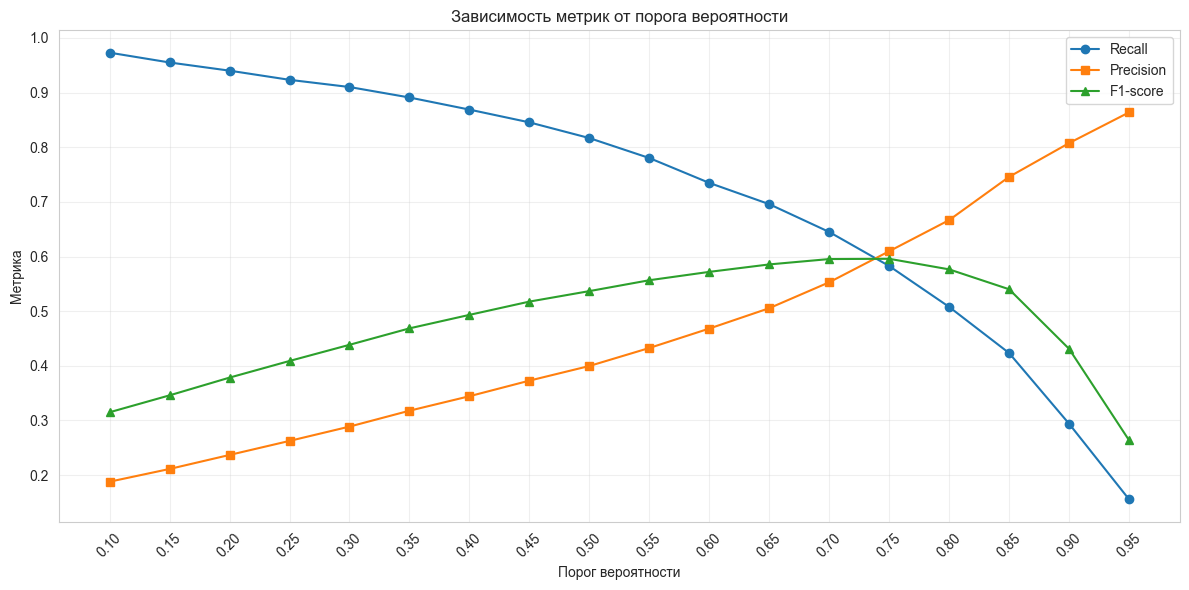

In [31]:
lr_model.plot_threshold_analysis(X_test, y_test)

In [81]:
lr_visualizer = ModelVisualizer(lr_model.model, X_test, y_test)

In [82]:
lr_visualizer.plot_roc_curve()

In [83]:
lr_visualizer.plot_precision_recall_curve()

In [85]:
lr_visualizer.plot_metrics_comparison()

ROC AUC: 0.8812
PR AUC: 0.6325
Precision: 0.3996
Recall: 0.8168
F1 Score: 0.5367


In [86]:
lr_visualizer.plot_confusion_matrix()

## Модель решающего дерева

In [46]:
from sklearn.tree import DecisionTreeClassifier


class DecisionTreeModel(BaseModel):

    def __init__(self, random_state: int = 42,
                 class_weight_options: List = None,
                 max_depth_range: List = None,
                 min_samples_split_range: List = None,
                 min_samples_leaf_range: List = None,
                 criterion_options: List = None):
        super().__init__(random_state)

        self.class_weight_options = class_weight_options or ['balanced', None]
        self.max_depth_range = max_depth_range or [None, 5, 10, 15, 20, 30]
        self.min_samples_split_range = min_samples_split_range or [2, 5, 10, 20]
        self.min_samples_leaf_range = min_samples_leaf_range or [1, 2, 4, 8]
        self.criterion_options = criterion_options or ['gini', 'entropy']

    def create_pipeline(self) -> Pipeline:
        return Pipeline([
            ('classifier', DecisionTreeClassifier(random_state=self.random_state))
        ])

    def get_param_grid(self) -> List[Dict]:
        return [{
            'classifier__max_depth': range(1, 4),
            'classifier__min_samples_split': [2, 5, 10, 15, 20],
            'classifier__min_samples_leaf': [1, 3, 5, 10, 15],
            'classifier__max_features': [None, 'sqrt', 'log2', 0.3, 0.5],
            'classifier__criterion': ['gini', 'entropy'],
            'classifier__class_weight': [None, 'balanced']
        }]


    def plot_tree_structure(self, columns) -> None:
        from sklearn import tree

        if self.model is None:
            raise ValueError("Модель не обучена. Сначала вызовите метод train()")

        tree_model = self.model.named_steps['classifier']

        plt.figure(figsize=(15, 10))
        tree.plot_tree(
            tree_model,
            feature_names=columns,
            class_names=["0 - не одобрено", "1 - одобрено"],
            filled=True,
        )
        plt.show()

    def plot_feature_importance(self, feature_names: List[str] = None) -> None:
        """
        Визуализация важности признаков для Decision Tree

        Args:
            feature_names: Список названий признаков
        """
        if self.model is None:
            raise ValueError("Модель не обучена. Сначала вызовите метод train()")

        feature = feature_names
        feature_importances = self.model.named_steps['classifier'].feature_importances_
        plt.figure(figsize=(15, 7))

        sns.barplot(x=feature, y=feature_importances)

        plt.title('Важность признаков')
        plt.xlabel('Признаки')
        plt.ylabel('Важность')
        plt.xticks(rotation=90)

        # plt.savefig('feature_importances.png', dpi=300, bbox_inches='tight')
        plt.show()

In [47]:
dt_model = DecisionTreeModel()
dt_model.train(X_train, y_train, cv=5)

Лучшие параметры: {'classifier__class_weight': 'balanced', 'classifier__criterion': 'entropy', 'classifier__max_depth': 3, 'classifier__max_features': None, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 2}
Лучшее качество на кросс-валидации: 0.8823


In [90]:
dt_visualizer = ModelVisualizer(dt_model.model, X_test, y_test)

In [91]:
dt_visualizer.plot_roc_curve()

In [92]:
dt_visualizer.plot_confusion_matrix()

In [94]:
dt_visualizer.plot_metrics_comparison()

ROC AUC: 0.8841
PR AUC: 0.7413
Precision: 0.7018
Recall: 0.7413
F1 Score: 0.7210


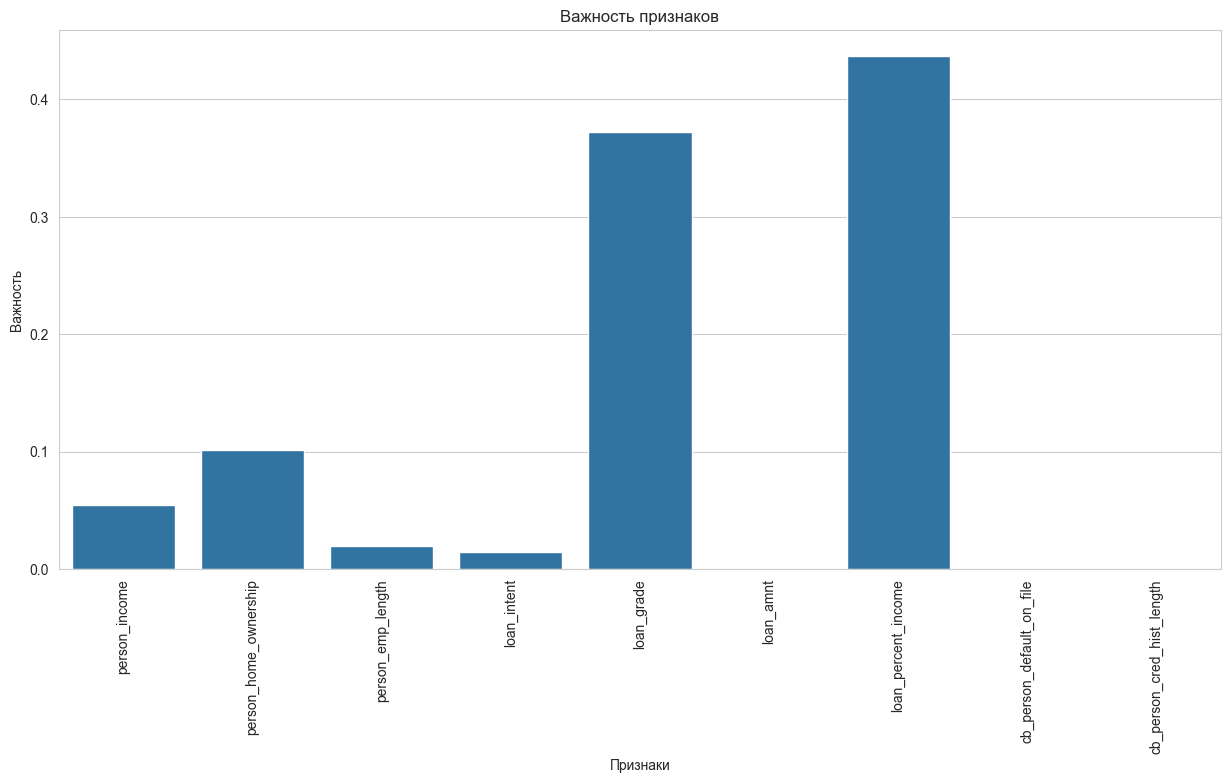

In [97]:
dt_model.plot_feature_importance(X_train.columns)

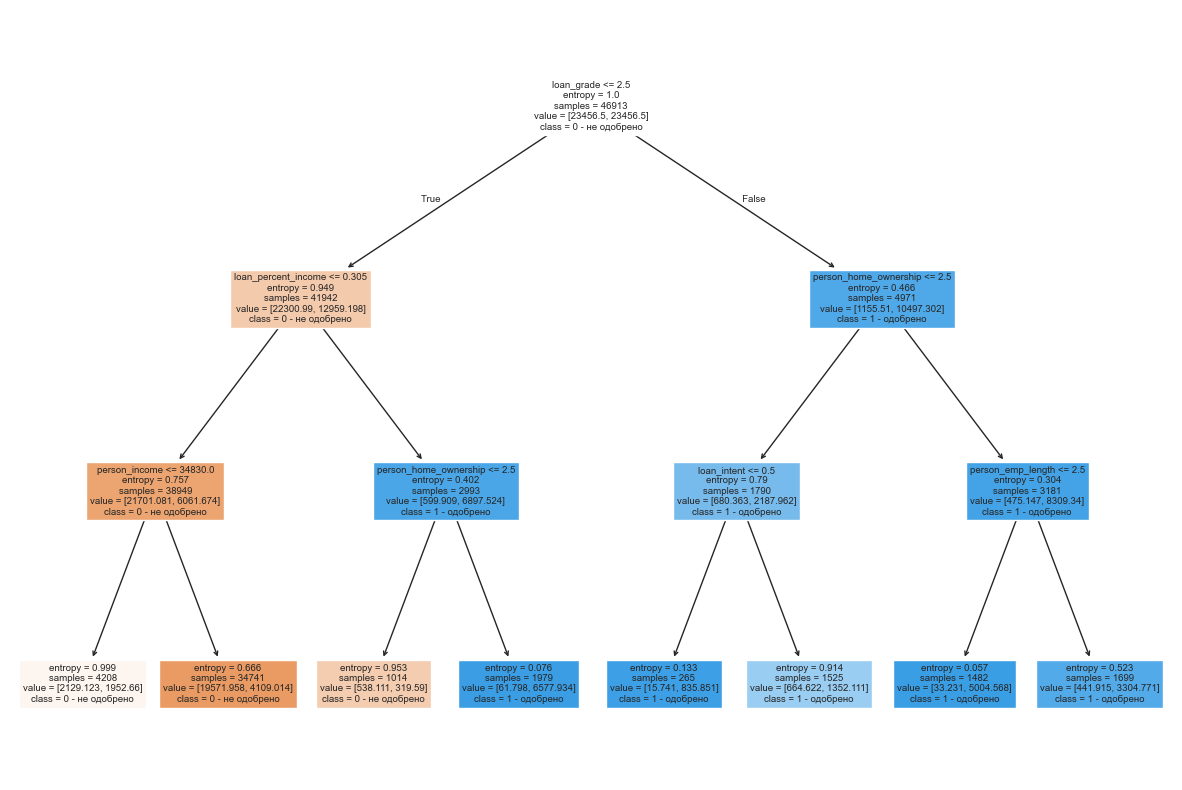

In [98]:
dt_model.plot_tree_structure(X_train.columns)

## XGBoost

In [53]:
from xgboost import XGBClassifier

class XGBoostModel(BaseModel):

    def create_pipeline(self) -> Pipeline:
        return Pipeline([
            ('classifier', XGBClassifier(random_state=self.random_state, use_label_encoder=False, eval_metric='logloss'))
        ])

    def get_param_grid(self) -> List[Dict]:
        return [{
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': [3, 5, 7, 9],
            'classifier__learning_rate': [0.01, 0.1, 0.3],
            'classifier__subsample': [0.8, 0.9, 1.0],
            'classifier__colsample_bytree': [0.8, 0.9, 1.0]
        }]

    def plot_feature_importance(self, feature_names: List[str] = None) -> None:
        if self.model is None:
            raise ValueError("Модель не обучена. Сначала вызовите метод train()")

        feature = feature_names
        feature_importances = self.model.named_steps['classifier'].feature_importances_
        plt.figure(figsize=(15, 7))

        sns.barplot(x=feature, y=feature_importances)

        plt.title('Важность признаков')
        plt.xlabel('Признаки')
        plt.ylabel('Важность')
        plt.xticks(rotation=90)

        plt.show()

In [54]:
xgboost_model = XGBoostModel()
xgboost_model.train(X_train, y_train, cv=5)

C:\Users\rusla\DataspellProjects\cred\venv\Lib\site-packages\xgboost\training.py:199: UserWarning: [18:54:27] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Лучшие параметры: {'classifier__colsample_bytree': 0.8, 'classifier__learning_rate': 0.3, 'classifier__max_depth': 3, 'classifier__n_estimators': 300, 'classifier__subsample': 1.0}
Лучшее качество на кросс-валидации: 0.9534


In [99]:
xgb_visualizer = ModelVisualizer(xgboost_model.model, X_test, y_test)

In [100]:
xgb_visualizer.plot_confusion_matrix()

In [101]:
xgb_visualizer.plot_roc_curve()

In [103]:
xgb_visualizer.plot_metrics_comparison()

ROC AUC: 0.9575
PR AUC: 0.8784
Precision: 0.9165
Recall: 0.7359
F1 Score: 0.8163


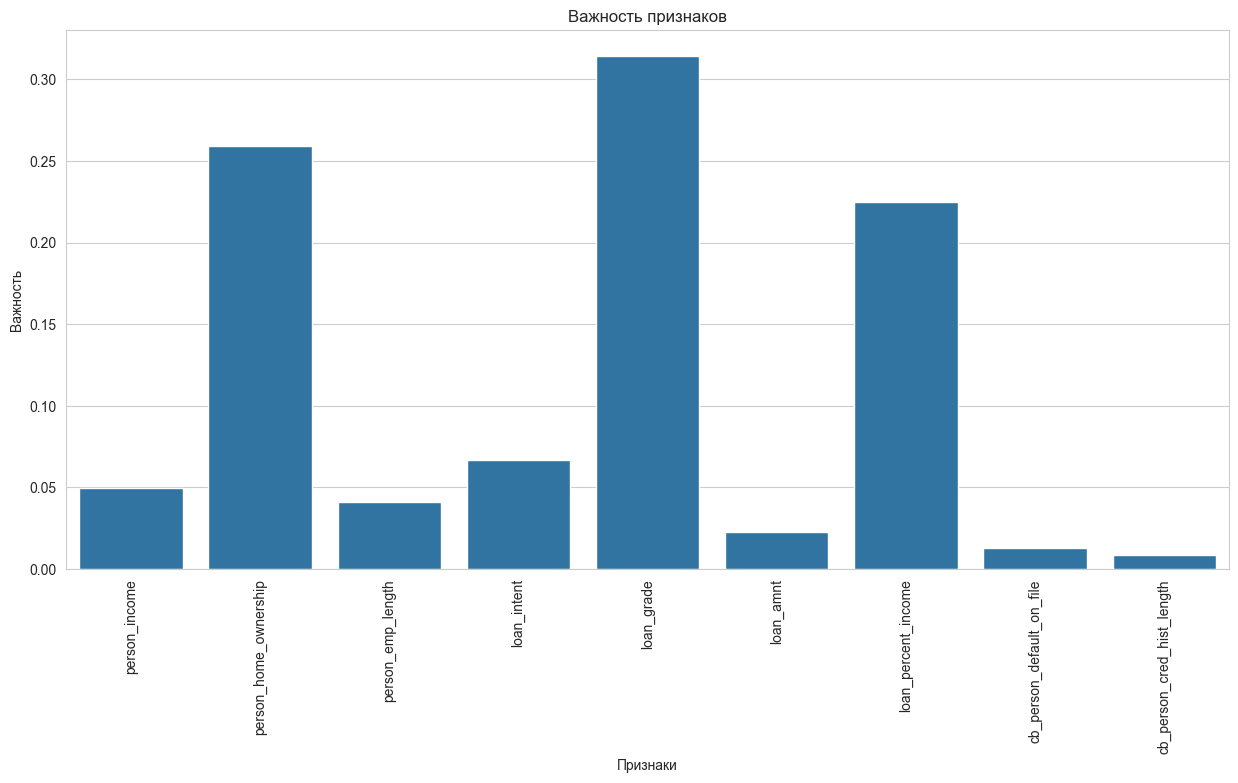

In [56]:
xgboost_model.plot_feature_importance(X_train.columns)

## Random Forest

In [57]:
from sklearn.ensemble import RandomForestClassifier

class RandomForestModel(BaseModel):
    def create_pipeline(self) -> Pipeline:
        return Pipeline([
            ('classifier', RandomForestClassifier(random_state=self.random_state))
        ])

    def get_param_grid(self) -> List[Dict]:
        return [{
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': range(1, 11),
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4],
            'classifier__class_weight': ['balanced', None]
        }]

    def plot_feature_importance(self, feature_names: List[str] = None) -> None:
        if self.model is None:
            raise ValueError("Модель не обучена. Сначала вызовите метод train()")

        feature = feature_names
        feature_importances = self.model.named_steps['classifier'].feature_importances_
        plt.figure(figsize=(15, 7))

        sns.barplot(x=feature, y=feature_importances)

        plt.title('Важность признаков')
        plt.xlabel('Признаки')
        plt.ylabel('Важность')
        plt.xticks(rotation=90)

        plt.show()



In [59]:
rf_model = RandomForestModel()

In [60]:
rf_model.train(X_train, y_train, cv=5)

Лучшие параметры: {'classifier__class_weight': None, 'classifier__max_depth': 10, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2, 'classifier__n_estimators': 200}
Лучшее качество на кросс-валидации: 0.9346


In [104]:
rf_visualizer = ModelVisualizer(rf_model.model, X_test, y_test)

In [105]:
rf_visualizer.plot_confusion_matrix()

In [106]:
rf_visualizer.plot_roc_curve()

In [107]:
rf_visualizer.plot_metrics_comparison()

ROC AUC: 0.9353
PR AUC: 0.8451
Precision: 0.9363
Recall: 0.6868
F1 Score: 0.7924


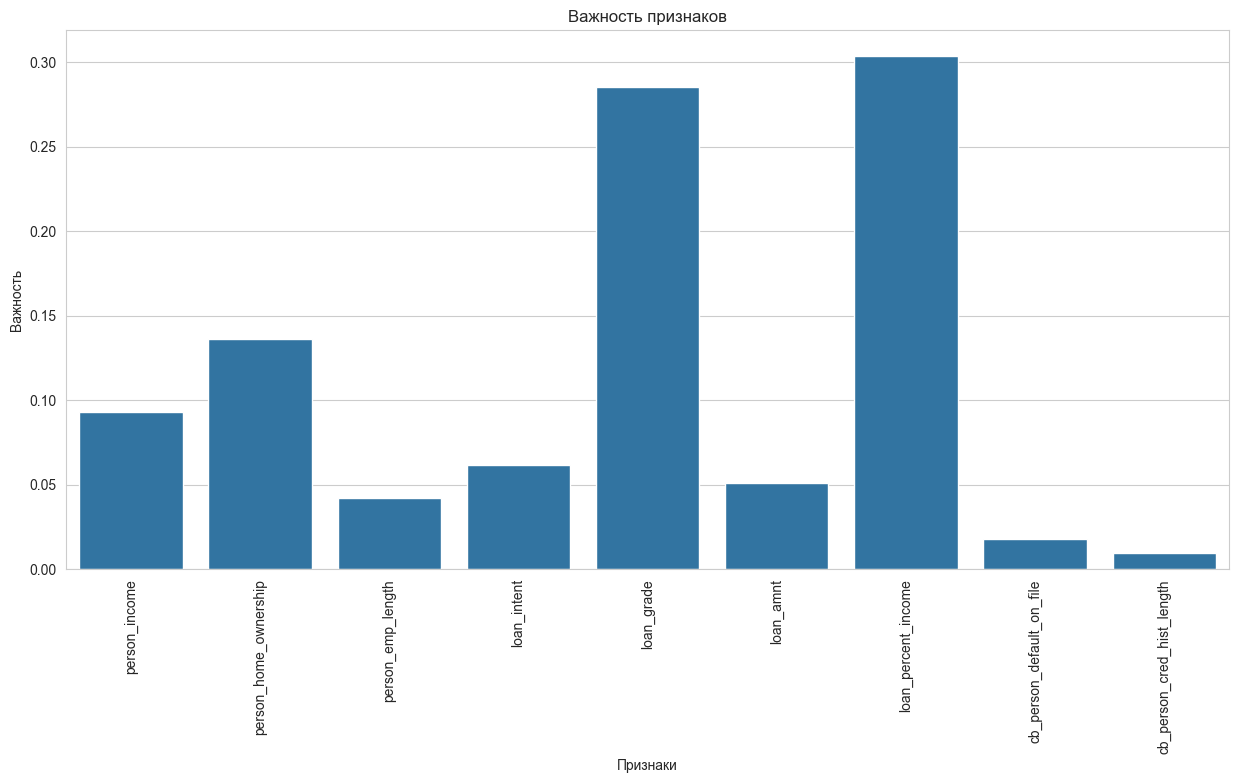

In [72]:
rf_model.plot_feature_importance(X_train.columns)

## LightGBM

In [65]:
from lightgbm import LGBMClassifier

class LightGBMModel(BaseModel):
    def create_pipeline(self) -> Pipeline:
        return Pipeline([
            ('classifier', LGBMClassifier(random_state=self.random_state))
        ])

    def get_param_grid(self) -> List[Dict]:
        return [{
            'classifier__n_estimators': [100, 200, 300],
            'classifier__max_depth': range(1, 11),
            'classifier__min_samples_split': [2, 5, 10],
            'classifier__min_samples_leaf': [1, 2, 4],
            'classifier__class_weight': ['balanced', None]
        }]

    def plot_feature_importance(self, feature_names: List[str] = None) -> None:
        if self.model is None:
            raise ValueError("Модель не обучена. Сначала вызовите метод train()")

        feature = feature_names
        feature_importances = self.model.named_steps['classifier'].feature_importances_
        plt.figure(figsize=(15, 7))

        sns.barplot(x=feature, y=feature_importances)

        plt.title('Важность признаков')
        plt.xlabel('Признаки')
        plt.ylabel('Важность')
        plt.xticks(rotation=90)

        plt.show()



In [66]:
lgbm_model = LightGBMModel()
lgbm_model.train(X_train, y_train)

[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=1. Current value: min_data_in_leaf=1
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=1. Current value: min_data_in_leaf=1
[LightGBM] [Warning] Unknown parameter: min_samples_split
[LightGBM] [Info] Number of positive: 6679, number of negative: 40234
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000393 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 567
[LightGBM] [Info] Number of data points in the train set: 46913, number of used features: 9
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.142370 -> initscore=-1.795744
[LightGBM] [Info] Start training from score -1.795744
[LightGBM] [Warning] No further s

In [108]:
lgbm_visualizer = ModelVisualizer(lgbm_model.model, X_test, y_test)

In [109]:
lgbm_visualizer.plot_confusion_matrix()

[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=1. Current value: min_data_in_leaf=1
[LightGBM] [Warning] Unknown parameter: min_samples_split


In [110]:
lgbm_visualizer.plot_roc_curve()

[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=1. Current value: min_data_in_leaf=1
[LightGBM] [Warning] Unknown parameter: min_samples_split


In [111]:
lgbm_visualizer.plot_metrics_comparison()

[LightGBM] [Warning] min_data_in_leaf is set with min_child_samples=20, will be overridden by min_samples_leaf=1. Current value: min_data_in_leaf=1
[LightGBM] [Warning] Unknown parameter: min_samples_split
ROC AUC: 0.9583
PR AUC: 0.8790
Precision: 0.9186
Recall: 0.7293
F1 Score: 0.8131


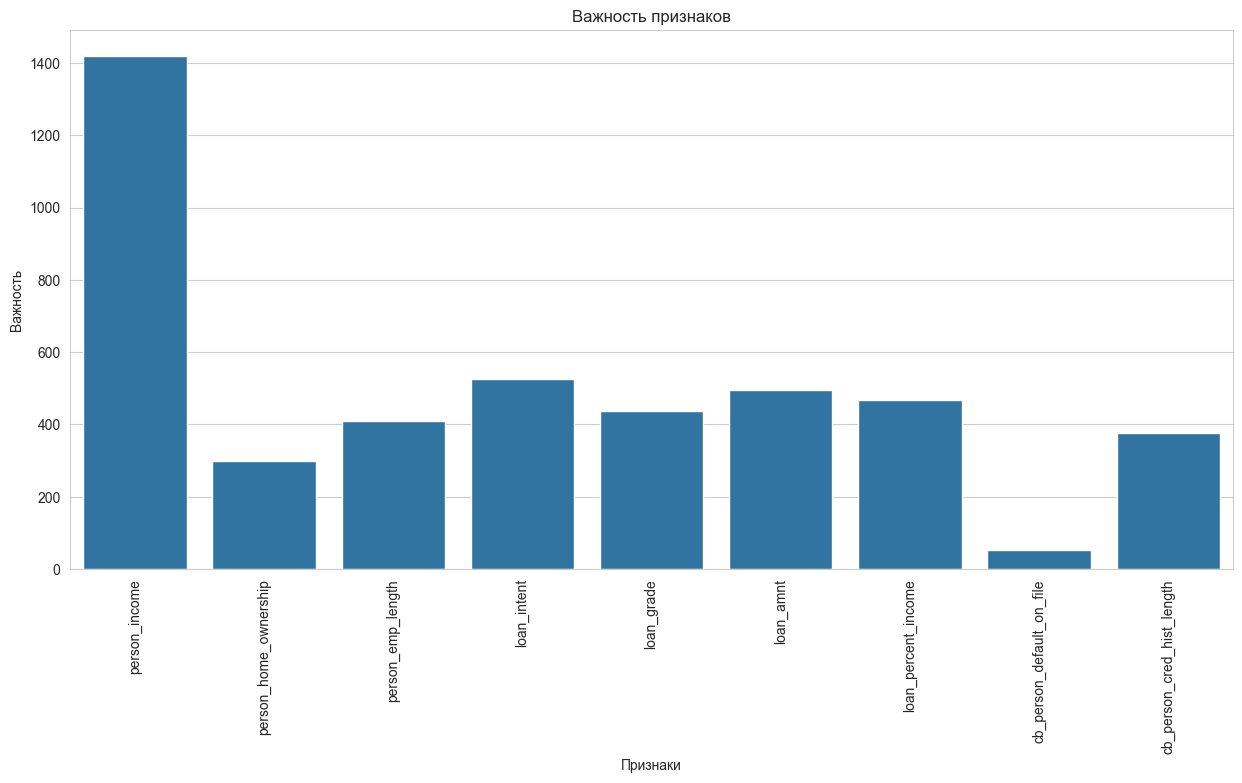

In [70]:
lgbm_model.plot_feature_importance(X_train.columns)